In [174]:
from langchain_core.messages import HumanMessage,SystemMessage
from langchain_mistralai import ChatMistralAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated,Literal
import operator
from dotenv import load_dotenv

In [175]:
load_dotenv()

True

In [176]:
generator_llm = ChatMistralAI(
    model="ministral-3b-latest",
    temperature=0.7
)

In [177]:
evaluator_llm = ChatMistralAI(
    model="mistral-large-latest",
    temperature=0.7
)

In [178]:
optimiser_llm =ChatMistralAI(
    model="mistral-small-latest",
    temperature=0.7
)

In [179]:
from pydantic import BaseModel, Field
from typing import Literal

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="Constructive feedback for the tweet.")

In [180]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [181]:
class XState(TypedDict):
    topic:str
    tweet:str
    evaluation : Literal["approved","needs_improvement"]
    tweet_list : Annotated[list[str],operator.add]
    feedback_list: Annotated[list[str],operator.add]
    feedback : str
    iteration : int
    max_iteration: int



In [182]:
#lets create graph
graph = StateGraph(XState)


In [183]:
def tweet_generator(state:XState)->XState:
  messages = [
    SystemMessage(content="You are a funny and clever Twitter/X influencer."),
    HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: {state['topic']}
        
        Rules:
        - Do NOT use question-answer format
        - Max 280 characters
        - Use observational humor, irony, sarcasm, or cultural references
        - Think in meme logic, punchlines, or relatable takes
        - Use simple, day-to-day English
    """)
]
  

  response = generator_llm.invoke(messages).content
  return{"tweet":response,"tweet_list":[response]}



In [184]:
def evaluator(state:XState)->XState:
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and format."),
    HumanMessage(content=f"""
        Evaluate the following tweet: {state['tweet']}
        
        Criteria:
        - Originality
        - Humor
        - Punchiness
        - Virality potential
        - Format (well-formed tweet, under 280 characters, not Q&A joke)
        
        Auto-reject if:
        - Written in question-answer format
        - Exceeds 280 characters
        - Ends with generic or deflating lines
        
        Respond only in this structured format:
        - Evaluation: "approved" or "needs_improvement"
        - One paragraph of feedback explaining strengths and weaknesses
    """)
]
    result = structured_evaluator_llm.invoke(messages)

    return {"evaluation":result.evaluation,"feedback":result.feedback,"feedback_list":[result.feedback]}



In [185]:
def optimiser(state:XState)->XState:
    messages = [
    SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
    HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
]
    result = optimiser_llm.invoke(messages)
    iteration = state["iteration"]+ 1
    return {"tweet":result.content,"iteration":iteration,"tweet_list":[result.content]}



In [186]:
def route_evaluation(state: XState):
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'


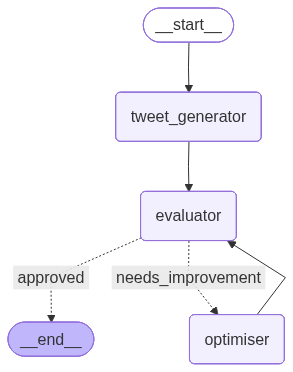

In [187]:
graph = StateGraph(XState)

graph.add_node("tweet_generator",tweet_generator)
graph.add_node("evaluator",evaluator)

graph.add_node("optimiser",optimiser)


graph.add_edge(START, "tweet_generator")
graph.add_edge('tweet_generator', 'evaluator')

graph.add_conditional_edges(
    'evaluator',
    route_evaluation,
    {'approved': END, 'needs_improvement': 'optimiser'}
)

graph.add_edge('optimiser', 'evaluator')

workflow = graph.compile()
workflow

In [188]:
initial_state = {
    "topic": "Indian Railways",
    "iteration": 1,
    "max_iteration": 5
}

final_state = workflow.invoke(initial_state)


In [189]:
print(final_state)

{'topic': 'Indian Railways', 'tweet': '**"Indian Railways: Where ‘On Time’ means ‘On Time… if you ignore the 100+ delays before that’ 🚆💨\n\nPro tip: Book a seat in the ‘Complaints’ section—you’ll be the first to get a ‘Sorry, we’re late, but not to *you*’ response."** 😂', 'evaluation': 'approved', 'tweet_list': ['**"Indian Railways: Where ‘On Time’ means ‘On Time… if you ignore the 100+ delays before that’ 🚆💨\n\nPro tip: Book a seat in the ‘Complaints’ section—you’ll be the first to get a ‘Sorry, we’re late, but not to *you*’ response."** 😂'], 'feedback_list': ["This tweet excels in humor and punchiness, leveraging a relatable frustration (Indian Railways' delays) with a sharp, witty twist. The 'Complaints section' joke is original and adds a fresh layer to a well-worn topic, while the playful tone keeps it engaging. The format is tight, well under 280 characters, and avoids the Q&A trap. Virality potential is high due to the universal annoyance it taps into, though adding a trending h